# 3.3 导读与数学基础：CTR 排序

> 阅读版与 Web 应用内容一致；实验数值来自本 Notebook 的已执行输出。

## Goal

在进入 DeepFM、DIN 与 DIEN 前，理解 logit、概率、交叉熵、AUC、特征交互、注意力和时序状态。

## Setup

本 Notebook 的默认真实数据是 **KuaiRand-Pure：真实短视频曝光、点击、长播与多反馈序列**。`smoke` 档读取仓库内可审计的确定性切片，`full` 档扩大到官方完整文件；两档都不制造交互、曝光、标签或行为序列。切片规则、源地址、哈希与许可记录在 `data/README.md` 及对应数据目录。

**主要资料：** [DeepFM](https://arxiv.org/abs/1703.04247) · [DIN](https://arxiv.org/abs/1706.06978) · [DIEN](https://arxiv.org/abs/1809.03672)

In [1]:
from pathlib import Path
import os, sys, json
import torch
ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
sys.path.insert(0, str(ROOT))
os.environ.setdefault("RECSYS_PROFILE", "full")
PROFILE = os.environ["RECSYS_PROFILE"]
CUDA_AVAILABLE = torch.cuda.is_available()
from recsys_lab.data import (load_movielens, movielens_provenance, load_amazon_2023,
                             amazon_provenance, load_kuairand, kuairand_provenance,
                             load_amazon_2018, amazon_2018_provenance,
                             load_movielens_1m, movielens_1m_provenance,
                             load_mind_amazon_books, mind_amazon_provenance,
                             load_census_income, census_income_provenance)
DATASET_KEY = "kuairand"
if DATASET_KEY == "movielens":
    real_ratings, real_movies = load_movielens()
    real_interactions = real_ratings
    REAL_DATASET = movielens_provenance(real_ratings)
elif DATASET_KEY == "amazon-books":
    real_ratings = load_amazon_2018("Books") if PROFILE == "full" else load_amazon_2023()
    real_interactions, real_movies = real_ratings, None
    REAL_DATASET = amazon_2018_provenance(real_ratings) if PROFILE == "full" else amazon_provenance(real_ratings)
elif DATASET_KEY == "mind-amazon-books":
    real_ratings = load_mind_amazon_books() if PROFILE == "full" else load_amazon_2023()
    real_interactions, real_movies = real_ratings, None
    REAL_DATASET = mind_amazon_provenance(real_ratings) if PROFILE == "full" else amazon_provenance(real_ratings)
elif DATASET_KEY == "amazon-electronics":
    real_ratings = load_amazon_2018("Electronics") if PROFILE == "full" else load_amazon_2023()
    real_interactions, real_movies = real_ratings, None
    REAL_DATASET = amazon_2018_provenance(real_ratings) if PROFILE == "full" else amazon_provenance(real_ratings)
elif DATASET_KEY == "movielens-1m":
    real_ratings = load_movielens_1m() if PROFILE == "full" else load_amazon_2023()
    real_interactions, real_movies = real_ratings, None
    REAL_DATASET = movielens_1m_provenance(real_ratings) if PROFILE == "full" else amazon_provenance(real_ratings)
elif DATASET_KEY == "census-income" and PROFILE == "full":
    census_train_x, census_train_y, census_test_x, census_test_y = load_census_income()
    real_interactions, real_movies, real_ratings = census_train_x, None, census_train_x
    REAL_DATASET = census_income_provenance()
elif DATASET_KEY == "amazon-2023":
    real_ratings = load_amazon_2023()
    real_interactions, real_movies = real_ratings, None
    REAL_DATASET = amazon_provenance(real_ratings)
else:
    real_interactions, real_movies = load_kuairand()
    real_ratings = real_interactions
    REAL_DATASET = kuairand_provenance(real_interactions)
print({"profile": PROFILE, "root": str(ROOT), "real_dataset": REAL_DATASET,
       "cuda_available": CUDA_AVAILABLE,
       "cuda_device": torch.cuda.get_device_name(0) if CUDA_AVAILABLE else None})
assert REAL_DATASET["randomly_fabricated_rows"] == 0

{'profile': 'smoke', 'root': '/workspace', 'real_dataset': {'dataset': 'KuaiRand-Pure (Kuaishou, CIKM 2022)', 'source': 'https://zenodo.org/records/10439422/files/KuaiRand-Pure.tar.gz', 'source_sha256': 'c814bf6f3624c0cfae83c57de3df26b2ed206e5c57bab4c4dcbfabbabe20cbf0', 'license_file': '/workspace/data/kuairand-pure/LICENSE', 'slice_rule': 'top 256 users by standard-feed interaction count; ties by user_id; all standard and random-policy rows for those users retained', 'profile': 'smoke', 'local_resource': '/workspace/data/kuairand-pure/standard_interactions.csv', 'rows_used': 39098, 'users_used': 128, 'items_used': 2500, 'time_min_utc': '2022-04-09T04:17:39+00:00', 'time_max_utc': '2022-05-08T15:50:58+00:00', 'targets': 'observed is_click, long_view, is_like and other feed feedback', 'randomly_fabricated_rows': 0}, 'cuda_available': False, 'cuda_device': None}


## 如何使用本导读

先阅读布局和论文问题，再运行共同数学演示。完成 Checks 后进入独立算法 Notebook；各算法会重新给出本模型的公式和更小的 Python 演示，不要求记住本页所有公式。

## 本章布局与选型地图

| 子章节 | 主要信号 | 关键机制 | 适用场景 |
|---|---|---|---|
| 3.3.1 DeepFM | 静态 sparse/dense fields | FM 二阶 + DNN 高阶 | 通用 CTR 基线 |
| 3.3.2 DIN | 候选 + 行为集合 | target-aware attention | 强历史、候选相关性 |
| 3.3.3 DIEN | 候选 + 有序行为 | GRU、辅助损失、AUGRU | 兴趣变化明显 |
| 3.3 总结 | 各实验 JSON | AUC、LogLoss、baseline | 效果—成本选型 |

由 DeepFM 到 DIN/DIEN，不是简单增加网络深度，而是逐步加入“当前候选”和“行为顺序”这两类结构先验。

## 来源论文解读

- **DeepFM (2017)** 共享 embedding 联合训练 FM 与 DNN，减少 Wide&Deep 宽侧的人工交叉。
- **DIN (2018)** 让同一用户面对不同候选时激活不同历史，固定用户向量变成候选感知表示。
- **DIEN (2019)** 用辅助下一行为监督兴趣抽取，再用 AUGRU 表达兴趣演化。

三者都在曝光样本上学习点击概率。若没有曝光日志，不能把“未点击”随意解释成真正负反馈。

## 数据选择：为什么使用 KuaiRand

本章使用 KuaiRand-Pure 的真实短视频曝光日志，而不是 MovieLens 评分。每条记录同时给出候选视频、场景、时间、是否点击和观看时长，因此 `is_click=0` 是一次真实未点击曝光，而不是从目录中人工抽出的负样本。这与 DeepFM、DIN、DIEN 的 CTR/序列排序问题更一致。

## 共同数学：概率、交叉熵、注意力与状态
排序模型先输出 logit $z$，Sigmoid 得 $p=\sigma(z)$。单样本 LogLoss 为

$$L=-[y\log p+(1-y)\log(1-p)]$$

AUC 可理解为随机取一对正负样本，正样本分数更高的概率。它看顺序，不保证概率校准。

DeepFM 关注 field 间交互；DIN 计算 $v=\sum_j a(e_j,e_t)e_j$；DIEN 再递推 $h_t=\mathrm{GRU}(e_t,h_{t-1})$。前者是加权和，后者让顺序改变最终状态。

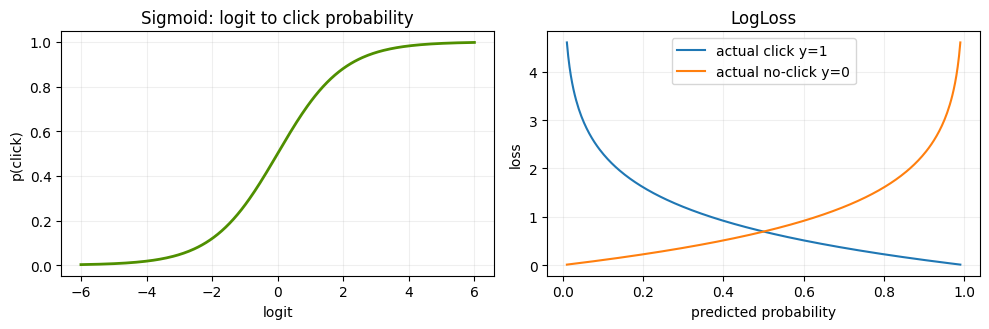

{'attention_weights': [0.457, 0.374, 0.168], 'weighted_interest': [0.757, 0.243]}


In [2]:
import numpy as np, matplotlib.pyplot as plt
z=np.linspace(-6,6,300); p=1/(1+np.exp(-z))
grid=np.linspace(.01,.99,300)
fig,axes=plt.subplots(1,2,figsize=(10,3.4))
axes[0].plot(z,p,color='#4f8f00',lw=2); axes[0].set(title='Sigmoid: logit to click probability',xlabel='logit',ylabel='p(click)'); axes[0].grid(alpha=.2)
axes[1].plot(grid,-np.log(grid),label='actual click y=1'); axes[1].plot(grid,-np.log(1-grid),label='actual no-click y=0')
axes[1].set(title='LogLoss',xlabel='predicted probability',ylabel='loss'); axes[1].legend(); axes[1].grid(alpha=.2)
plt.tight_layout(); plt.show()
history=np.array([[1.,0.],[.8,.2],[0.,1.]]); target=np.array([1.,0.]); raw=history@target; weight=np.exp(raw)/np.exp(raw).sum()
print({'attention_weights':weight.round(3).tolist(),'weighted_interest':(weight@history).round(3).tolist()})

## 学习顺序

1. 说清业务阶段和输入输出；2. 手算共享数学；3. 进入每个独立算法；4. 执行训练与推理；5. 最后打开章节总结读取实际结果。

## Checks

In [3]:
positive=np.array([.9,.7,.6]); negative=np.array([.8,.4,.2])
auc=(positive[:,None]>negative[None,:]).mean()
assert 0<=auc<=1 and np.isclose(weight.sum(),1)
print({'AUC_as_pairwise_win_rate':round(float(auc),3),'attention_sum':round(float(weight.sum()),3)})

{'AUC_as_pairwise_win_rate': 0.778, 'attention_sum': 1.0}


## Next Steps

从左侧 Notebook 导航进入本章第一个算法。遇到公式时依次检查：符号代表什么、数组形状是什么、用小数字怎么算、代码输出是否符合直觉。